<a href="https://colab.research.google.com/github/Nicolas-Bernal/Simulacion-Estadistica/blob/main/Segundo%20Corte/00_Taller.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller 2 Simulacion Estadistica

## Nicolas Alexander Bernal Rubio

## Paula Andrea Castellanos González


In [ ]:
# Librerias necesarias

install.packages("plot3D")
require("plot3D")

install.packages("ks")
require("ks")


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘misc3d’


Loading required package: plot3D

Warning message:
“no DISPLAY variable so Tk is not available”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘FNN’, ‘kernlab’, ‘mclust’, ‘multicool’, ‘mvtnorm’, ‘pracma’


Loading required package: ks



In [ ]:
install.packages("MASS")
require("MASS")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: MASS



# Ejercicio 1

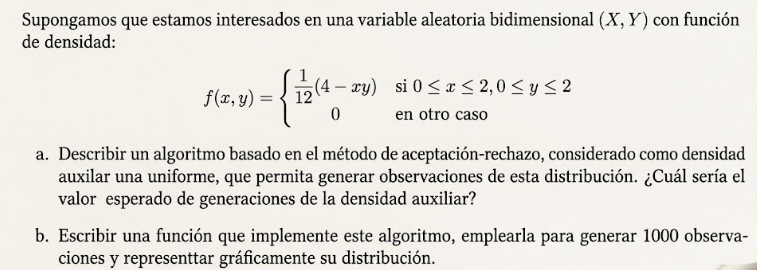

## $a)$

**Densidades y Constantes:**
* **Densidad Objetivo:** $f(x,y) = \frac{1}{12}(4 - xy)$ para $x, y \in [0, 2]$

* **Densidad Auxiliar (Uniforme):** $g(x,y) = \frac{1}{4}$ para $x, y \in [0, 2]$
* $M = \max f(x,y) = f(0,0) = \frac{1}{3}$
* $c = \frac{M}{g(x,y)} = \frac{1/3}{1/4} = \frac{4}{3} \approx 1.3333$

---

1. Definir las constantes $M = \frac{1}{3}$ y $c = \frac{4}{3}$.

2. Simular de forma independiente $T_1 \sim \mathcal{U}(0, 2)$ y $T_2 \sim \mathcal{U}(0, 2)$.
3. Simular una variable uniforme estándar $U \sim \mathcal{U}(0, 1)$.
4. **Evaluar Aceptación:**
   $$\text{Si } U \le 1 - \frac{T_1 T_2}{4}, \text{ aceptar } (X, Y) = (T_1, T_2)$$
5. De lo contrario, descartar $(T_1, T_2)$ y volver al **Paso 2**.
6. los pasos 2 a 5 hasta completar $n = 1000$ observaciones aceptada.

---

### **Valor Esperado de Generaciones**

El número de intentos hasta obtener una observación aceptada sigue una distribución geométrica con probabilidad de éxito $p = \frac{1}{c} = \frac{3}{4}$.

$$\mathbb{E}[N] = c = \frac{4}{3} \approx 1.3333 \text{ generaciones de la densidad auxiliar por cada observación aceptada.}$$

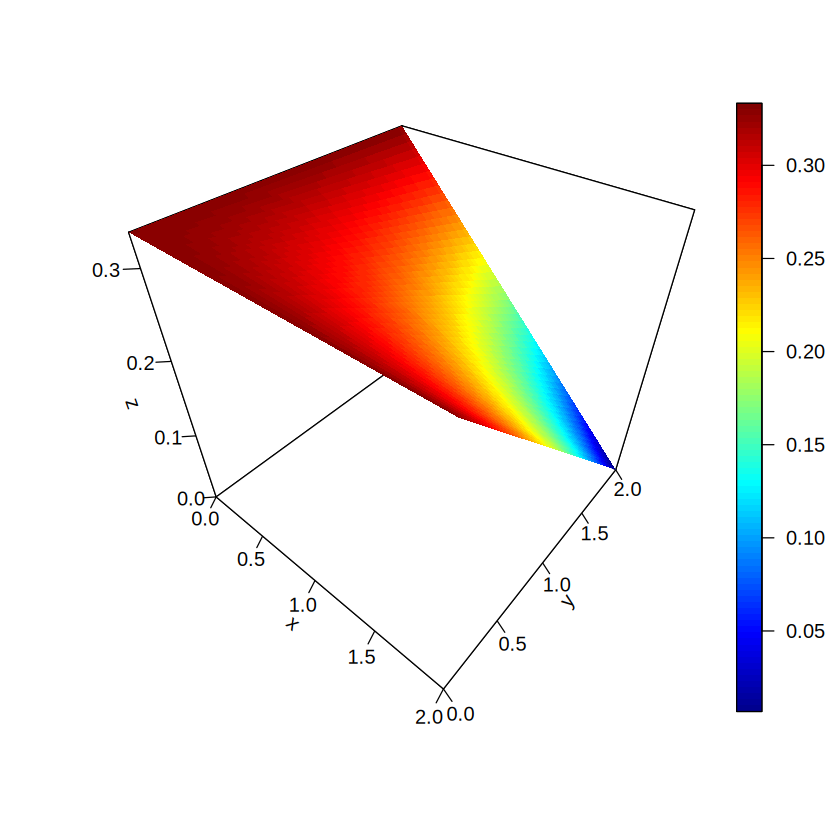

In [ ]:
f = function(x, y) {
  (4 - x * y) / 12
}

persp.f2D = function(f2d, ax = 0, bx = 2, ay = 0, by = 2, nx = 21, ny = 21, ...) {
  x = seq(ax, bx, length = nx)
  y = seq(ay, by, length = ny)
  z = outer(x, y, f2d)

  plot3D::persp3D(x, y, z, ...)
}

persp.f2D(f, 0, 2, 0, 2, 50, 50, ticktype = "detailed")

In [ ]:
ngen = 0

rf = function() {

  # Simulación por aceptación y rechazo a partir de Uniforme

  # g(x,y) = 1/4  =>  M = max(f) = 1/3  =>  M / g = (1/3) / (1/4) = 4/3

  m = 1/3

  while(TRUE) {

    u = runif(1)
    x = runif(2, 0, 2)  # Dominio [0, 2] x [0, 2]
    ngen <<- ngen + 1

    if (m * u <= f(x[1], x[2])) {
      return(x)
    }
  }
}

In [ ]:

rfn = function(n = 1000) {
  ngen <<- 0
  # Simulación n valores

  x = matrix(nrow = n, ncol = 2)
  for(i in 1:n) {
    x[i, ] = rf()
  }
  return(x)
}

   user  system elapsed 
  0.009   0.000   0.010 

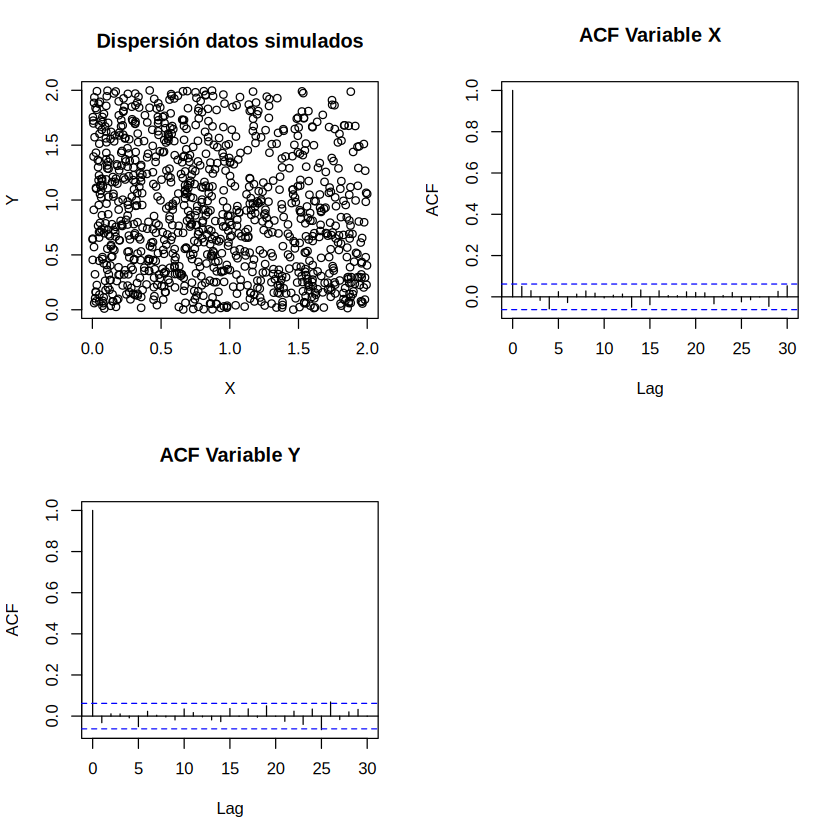

In [ ]:
set.seed(1)
nsim = 1000
datos = rfn(nsim)

system.time(rfn(nsim))

par(mfrow = c(2,2))

plot(datos, xlab = "X", ylab = "Y", main = "Dispersión datos simulados")

acf(datos[,1], main = "ACF Variable X")
acf(datos[,2], main = "ACF Variable Y")

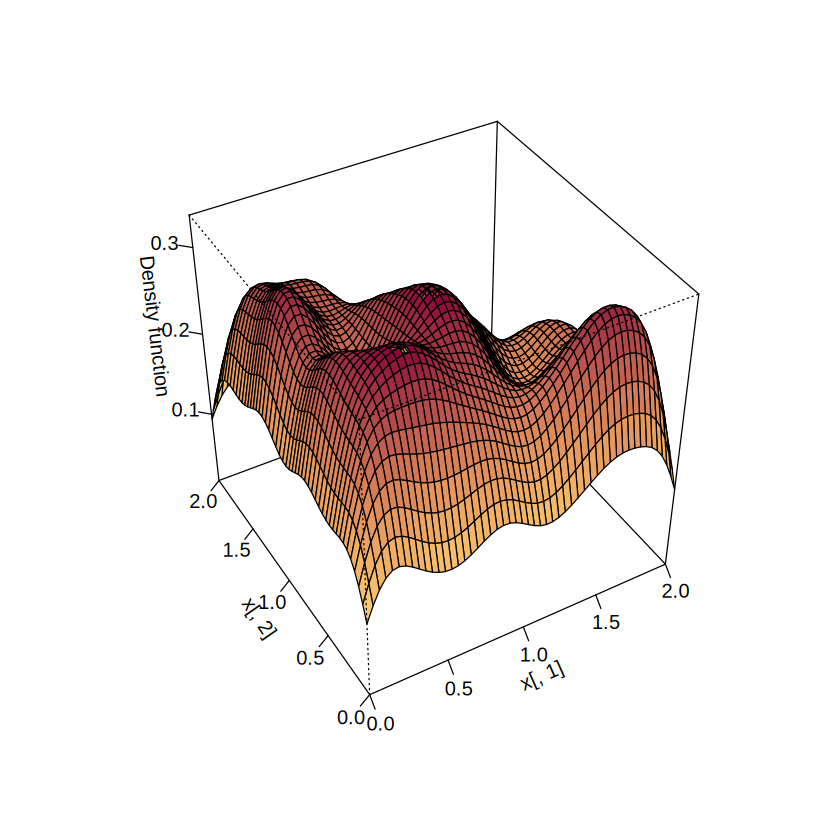

In [ ]:
H_matrix = Hscv(x = datos)

fhat = kde(x = datos, H = H_matrix, xmin = c(0,0), xmax = c(2,2))

plot(fhat, display = "persp")